# What Drives Purchase Behavior in Social E-commerce?
This project analyzes user behavior data to identify key factors that influence purchase decisions and translate them into actionable business insights.

https://www.kaggle.com/datasets/xingkuichenjin/social-ecommerce-data


# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics
import shap

# Load data

The dataset is loaded and a working copy is created for analysis.  
Unnecessary identifier columns such as `user_id` and `item_id` are removed, as they do not contribute to behavioral modeling.

In [3]:
file_path = 'social_ecommerce_data.csv'

original_df = pd.read_csv(file_path)
df= original_df.copy().drop(columns=['user_id', 'item_id'])
df.head()

,age,gender,user_level,purchase_freq,total_spend,register_days,follow_num,fans_num,price,discount_rate,...,add2cart,coupon_received,coupon_used,pv_count,last_click_gap,interaction_rate,purchase_intent,freshness_score,social_influence,label
0,18,0,1,9,2675.46,1463,30,0,21.04,0.220,...,0,0,0,20,19.1,62.429,14.6,0.557,312.14,0
1,18,1,4,43,3750.26,450,16,1,171.95,0.000,...,1,0,0,13,5.5,0.393,5.1,0.814,1.96,1
2,36,1,7,5,801.80,801,41,0,107.82,0.000,...,0,0,0,1,0.7,2.500,0.0,0.972,12.50,1
3,20,1,4,33,3903.82,243,65,8,115.44,0.125,...,1,0,0,5,5.5,1.417,5.1,0.814,7.08,1
4,23,0,6,12,2856.42,609,9,0,66.69,0.000,...,0,1,0,59,8.5,0.425,3.3,0.738,2.12,1


# Exploratory Data Analysis (EDA)

## Data Overview

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   age               100000 non-null  int64  
 1   gender            100000 non-null  int64  
 2   user_level        100000 non-null  int64  
 3   purchase_freq     100000 non-null  int64  
 4   total_spend       100000 non-null  float64
 5   register_days     100000 non-null  int64  
 6   follow_num        100000 non-null  int64  
 7   fans_num          100000 non-null  int64  
 8   price             100000 non-null  float64
 9   discount_rate     100000 non-null  float64
 10  category          100000 non-null  object 
 11  title_length      100000 non-null  int64  
 12  title_emo_score   100000 non-null  float64
 13  img_count         100000 non-null  int64  
 14  has_video         100000 non-null  int64  
 15  like_num          100000 non-null  int64  
 16  comment_num       100

In [5]:
df.describe()

,age,gender,user_level,purchase_freq,total_spend,register_days,follow_num,fans_num,price,discount_rate,...,add2cart,coupon_received,coupon_used,pv_count,last_click_gap,interaction_rate,purchase_intent,freshness_score,social_influence,label
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,27.099540,0.363160,3.924760,11.577360,2703.603992,545.105660,19.479300,0.645110,110.213719,0.114978,...,0.234090,0.201010,0.115530,9.264120,12.010183,15.070041,2.754279,0.722855,76.758312,0.449830
std,7.030909,0.480913,1.581089,10.041206,3013.396298,288.609164,25.538132,2.799522,121.654247,0.130397,...,0.423431,0.400758,0.319662,11.540215,12.075282,95.234946,6.096262,0.180452,476.191511,0.497479
min,18.000000,0.000000,1.000000,0.000000,39.730000,1.000000,0.000000,0.000000,1.430000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.100000,0.000000,0.000000,0.127000,0.000000,0.000000
25%,21.000000,0.000000,3.000000,5.000000,981.425000,339.000000,6.000000,0.000000,40.060000,0.000000,...,0.000000,0.000000,0.000000,3.000000,3.400000,0.562000,0.200000,0.591000,3.930000,0.000000
50%,27.000000,0.000000,4.000000,9.000000,1799.485000,541.000000,12.000000,0.000000,73.600000,0.075000,...,0.000000,0.000000,0.000000,6.000000,8.300000,2.750000,1.100000,0.743000,15.840000,0.000000
75%,32.000000,1.000000,5.000000,15.000000,3304.305000,742.000000,23.000000,0.000000,135.180000,0.205000,...,0.000000,0.000000,0.000000,11.000000,16.600000,10.042000,5.000000,0.876000,51.880000,1.000000
max,64.000000,1.000000,7.000000,50.000000,50000.000000,1822.000000,500.000000,337.000000,3299.410000,0.643000,...,1.000000,1.000000,1.000000,100.000000,165.500000,9850.375000,756.700000,0.996000,49251.880000,1.000000


In [6]:
df.duplicated().sum()

np.int64(0)

The dataset contains 100,000 records and 30 features.  
There are no missing values and no duplication, and most features are numeric, with only one categorical variable (`category`).

## Target Distribution

In [7]:
df['label'].value_counts()

label
0    55017
1    44983
Name: count, dtype: int64

The dataset contains 100,000 records and 30 features with no missing values or duplicates. 

The target variable (label) is reasonably balanced with 55% non-purchase vs 45% purchase. 

No special handling is needed for class imbalance.

## Mutual Information

In [8]:
X = df.drop(columns=['label'])
X['category'] = X['category'].astype('category').cat.codes
y = df['label']

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_results = pd.Series(mi_scores, name="MI Scores", index=X.columns).sort_values(ascending=False)
mi_results.head(10)

purchase_intent     0.072577
add2cart            0.071561
coupon_used         0.020512
coupon_received     0.013053
user_level          0.012812
social_influence    0.009192
freshness_score     0.009079
last_click_gap      0.008965
is_follow_author    0.007151
interaction_rate    0.006465
Name: MI Scores, dtype: float64

### Key findings:
- The top MI features include `purchase_intent`, `add2cart`, `coupon_used`. They will be excluded from this section as they represent behaviors occurring at or after the purchase decision. They will be examined in the modeling section.

- `social_influence` and `freshness_score` showed low MI scores with no strong business rationale for further investigation and were excluded to keep the analysis focused.

- EDA will focus on features that represent pre-purchase drivers.

## Users Factors

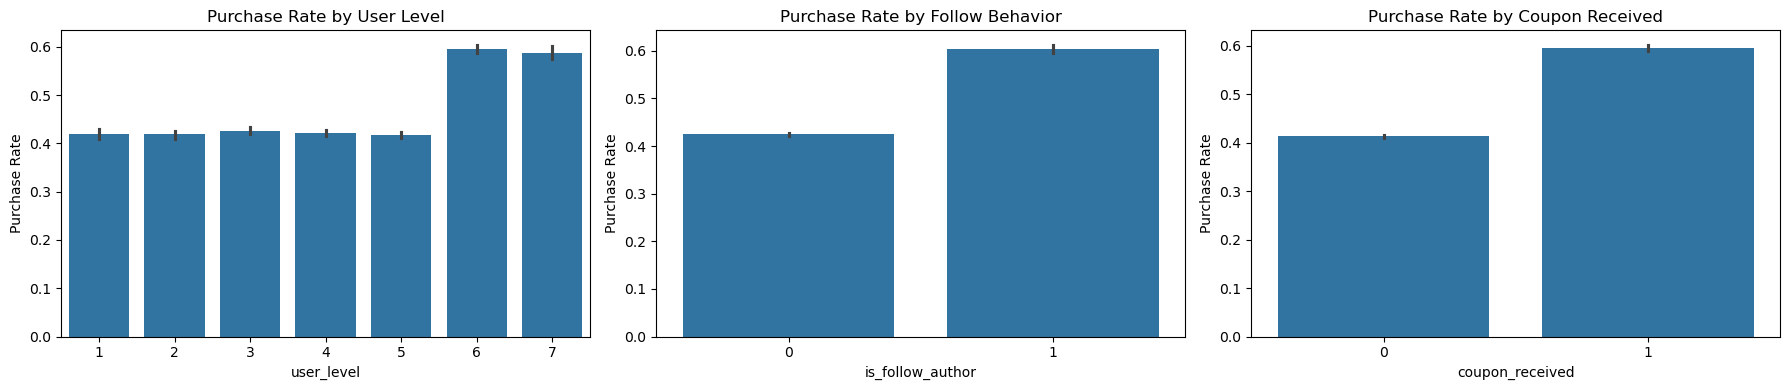

In [9]:
fig, axes= plt.subplots(1,3, figsize= (18,4))

sns.barplot(data=df, x='user_level', y='label', ax=axes[0])
sns.barplot(data=df, x='is_follow_author', y='label', ax=axes[1])
sns.barplot(data=df, x='coupon_received', y='label', ax=axes[2])

axes[0].set_title('Purchase Rate by User Level')
axes[1].set_title('Purchase Rate by Follow Behavior')
axes[2].set_title('Purchase Rate by Coupon Received')

for ax in axes:
    ax.set_ylabel('Purchase Rate')

plt.tight_layout()
plt.show() 

### Key Findings:

- Users at level 6-7 purchase at significantly higher rates than level 1-5, suggesting that platform experience or loyalty is a strong purchase driver. 
- Users who follow authors tend to purchase more, suggesting that creator relationships build trust and inspired purchase decision.
- Users who received coupons are more likely to purchase. However this relationship may reflect purchase intent rather than coupon influence. Users who already intent to buy maybe more likely to actively seek out coupons.



## Product Factors

Text(0.5, 0, 'Category')

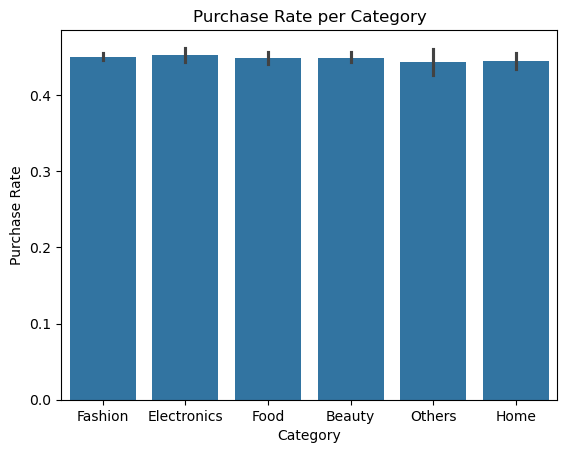

In [10]:
mapping ={
    '服饰鞋包': 'Fashion',
    '美妆个护': 'Beauty',
    '食品生鲜': 'Food',
    '数码家电': 'Electronics',
    '家居日用': 'Home',
    '其他': 'Others'
}

df['category_en']= df['category'].map(mapping)

sns.barplot(data=df, x='category_en', y= 'label')
plt.title('Purchase Rate per Category')
plt.ylabel('Purchase Rate')
plt.xlabel('Category')

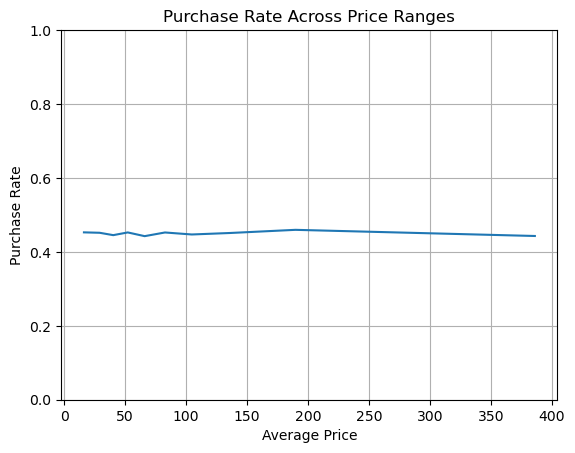

In [20]:
df['price_bin'] = pd.qcut(df['price'], q=10, duplicates='drop')

price_conversion = (
    df.groupby('price_bin', observed=True)
      .agg(price_mid=('price', 'mean'),purchase_rate=('label', 'mean'))
      .reset_index())

sns.lineplot(data=price_conversion, x='price_mid', y='purchase_rate')
plt.xlabel('Average Price')
plt.ylabel('Purchase Rate')
plt.title('Purchase Rate Across Price Ranges')
plt.ylim(0, 1)
plt.grid(True)

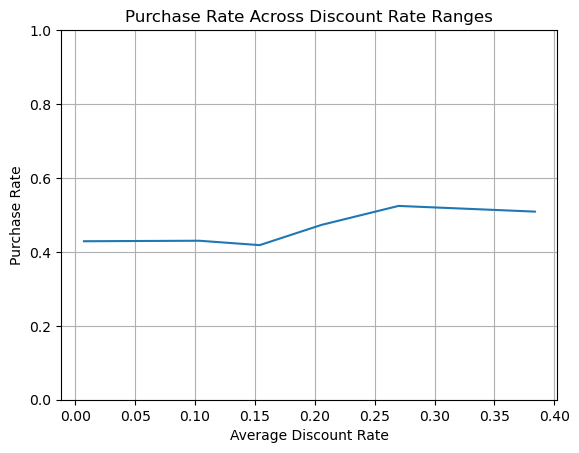

In [12]:
df['discount_rate_bin'] = pd.qcut(df['discount_rate'], q=10, duplicates='drop')

discount_rate_conversion = (
    df.groupby('discount_rate_bin', observed=True)
      .agg(discount_rate_mid=('discount_rate', 'mean'),purchase_rate=('label', 'mean'))
      .reset_index())

sns.lineplot(data= discount_rate_conversion, x='discount_rate_mid', y='purchase_rate')
plt.xlabel('Average Discount Rate')
plt.ylabel('Purchase Rate')
plt.title('Purchase Rate Across Discount Rate Ranges')
plt.ylim(0, 1)
plt.grid(True)

### Key Findings:
- Category doesn't seem to have impact on purchase
- Purchase rate remains flat across all price ranges, suggesting price alone doesn't influence purchase decision.
- When Discount Rates exceed 20%, purchase rate increase noticeably, suggesting there is a threshold effect

## Behavioral/Timing Factor

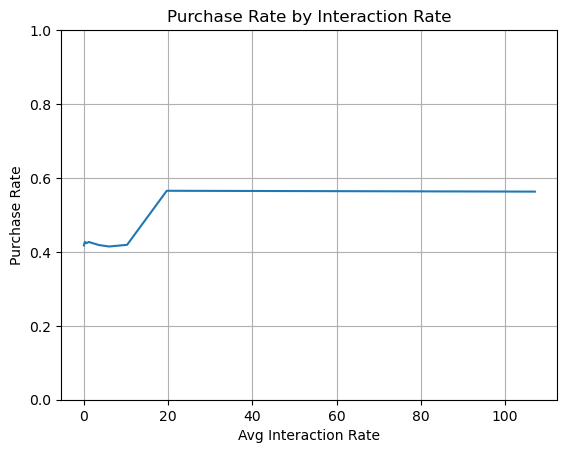

In [13]:
df['interaction_bin']= pd.qcut(df['interaction_rate'], q=10, duplicates='drop')

interaction_conversion= df.groupby('interaction_bin', observed= True).agg(
    gap_mid= ('interaction_rate', 'mean'),
    purchase_rate= ('label', 'mean')). reset_index()

sns.lineplot(data= interaction_conversion, y='purchase_rate', x='gap_mid')
plt.xlabel('Avg Interaction Rate')
plt.ylabel('Purchase Rate')
plt.title('Purchase Rate by Interaction Rate')
plt.ylim(0,1)
plt.grid(True)

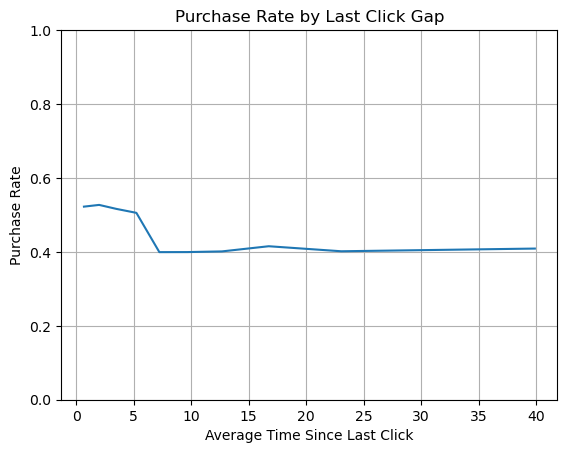

In [14]:
df['click_gap_bin'] = pd.qcut(df['last_click_gap'], q=10, duplicates='drop')

gap_conversion = (
    df.groupby('click_gap_bin', observed=True)
    .agg(gap_mid=('last_click_gap', 'mean'), purchase_rate=('label', 'mean'))
    .reset_index())

sns.lineplot(data=gap_conversion, x='gap_mid', y='purchase_rate')
plt.xlabel('Average Time Since Last Click')
plt.ylabel('Purchase Rate')
plt.title('Purchase Rate by Last Click Gap')
plt.ylim(0, 1)
plt.grid(True)

### Key Insights:
- Users who interacted more frequently show a noticeably higher purchase rate, with the effect becoming stable beyond interaction rate of 20. While the gap is moderate, it represents a meaningful conversion difference at scale
- Purchase rate is higher within the first 5 days of interaction, dropping at day 6 and remaining flat thereafter. This suggests that business should prioritize re-engagement within 5 days of user interaction. 

## EDA Summary:
- EDA suggests that purchase behavior is driven by:
   - user maturity (level 6-7)
   - social trust (following author)
   - perceived values (discount rate above 20%)
   - active engagement (interaction above 20%)
   - recency of interaction (within 5 days)
   - price and product category show little influence

# Modeling

In [15]:
cols_to_drop= ['label', 'category', 'price_bin', 'discount_rate_bin', 'interaction_bin', 'click_gap_bin']
X= df.drop(columns= cols_to_drop)
y= df['label']

categorical= ['category_en']
numerical= [col for col in X.columns if col not in categorical]

preprocessor= ColumnTransformer([
    ('num', 'passthrough', numerical),
    ('cat', OneHotEncoder(handle_unknown= 'ignore'), categorical)
])

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state= 42, stratify= y)

xgb_pipe= Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(random_state= 42))
])

In [16]:
%%time

xgb_pipe.fit(X_train, y_train)

CPU times: user 1.49 s, sys: 443 ms, total: 1.94 s
Wall time: 290 ms


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [17]:
y_pred= xgb_pipe.predict(X_test)
y_proba= xgb_pipe.predict_proba(X_test)[:, 1]

print("Test AUC:", metrics.roc_auc_score(y_test, y_proba))
print(metrics.classification_report(y_test, y_pred))

Test AUC: 0.7668606117718803
              precision    recall  f1-score   support

           0       0.71      0.79      0.75     11003
           1       0.71      0.61      0.65      8997

    accuracy                           0.71     20000
   macro avg       0.71      0.70      0.70     20000
weighted avg       0.71      0.71      0.71     20000



The model achieves an AUC of 0.77, indicating it has learned meaningful patterns from the data. 

This is sufficient for the purpose of this project, which is to use SHAP to identify and interpret the key drivers of purchase behavior, rather than to deploy a production classifier.

# SHAP

In [18]:
preprocessor= xgb_pipe.named_steps['preprocessor']
model= xgb_pipe.named_steps['model']

X_test_transform= preprocessor.transform(X_test)
feature_names= preprocessor.get_feature_names_out()

explainer= shap.TreeExplainer(model)
shap_values= explainer.shap_values(X_test_transform)

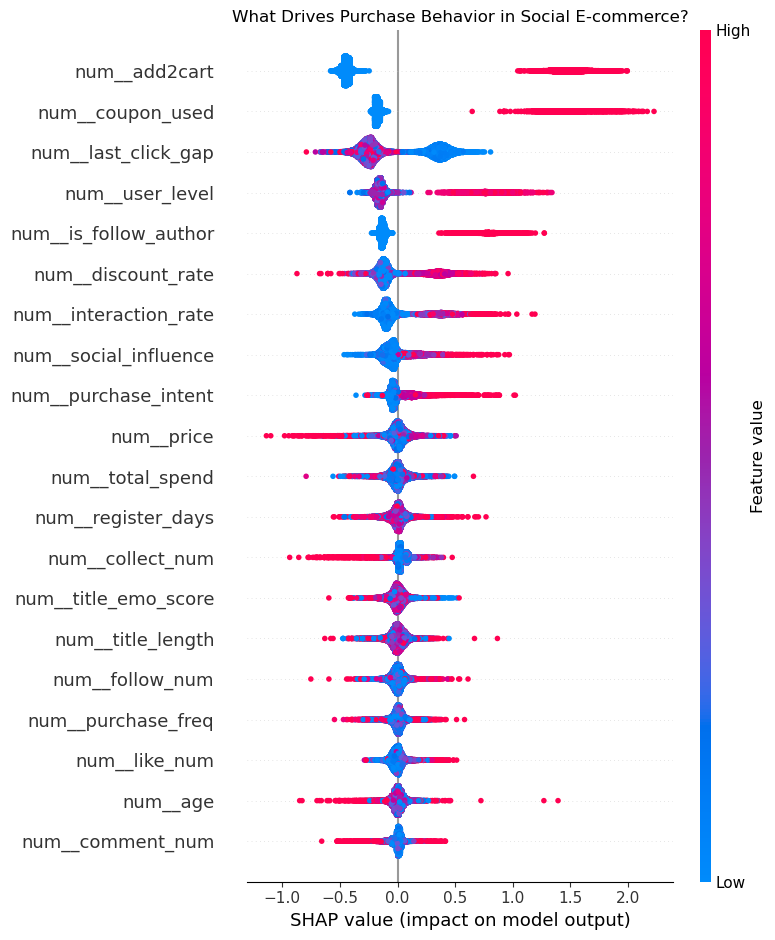

In [19]:
plt.figure(figsize= (8,6))

shap.summary_plot(
    shap_values, 
    X_test_transform,
    feature_names= feature_names,
    show= False)

plt.title("What Drives Purchase Behavior in Social E-commerce?")
plt.tight_layout()
plt.show()

### SHAP Interpretation
- SHAP analysis identifies three strong conversion signals: `add2cart`, `coupon_used`, and `purchase_intent`. These features show that high values strongly push predictions toward purchase. They represent behaviors that occur when a user has already decided to buy, indicating that the purchase decision has effectively been made.

- Several features drive purchase intent before conversion signals appear.

     - High user levels strongly increase purchase likelihood, however, a small cluster of high-level users still falls below zero, suggesting that experience alone does not guarantee purchase, possibly due to more critical evaluation behavior. Low-level users consistently show negative impact.

     - Users who follow an author are more likely to purchase, suggesting that creator relationships build trust and influence decisions.

     - The longer the gap since last interaction, the less likely a user is to purchase, indicating that purchase intent decays quickly over time.

     - Higher discount rates encourage purchase, particularly beyond the 20% threshold identified in EDA.

     - Notably, `social_influence` showed a low MI score in EDA but emerged as a meaningful driver in SHAP, highlighting that MI scores alone can underestimate feature importance.

 - Features such as `collect_num`, `coupon_received`, `like_num`, `purchase_freq`, and `img_count` show minimal SHAP impact and are not meaningful drivers of purchase behavior.


Together, these findings suggest that purchase behavior follows two distinct stages: Pre-decision drivers such as user level, creator trust, recency of interaction, and discount rate build purchase intent, while conversion signals such as `add2cart`, `coupon_used`, and `purchase_intent` indicate that the user is completing the purchase.

# Business Recommendations & Conclusion.

1. Target high-experience users (level 6–7) with priority campaigns. They show significantly higher purchase rates than lower-level users, making them the most valuable segment to focus marketing efforts on.

2. Apply discounts strategically, particularly above the 20% threshold. EDA and SHAP both confirm that discount rates below 20% have limited impact, while deeper discounts meaningfully increase purchase likelihood.

3. Reduce friction in the add-to-cart flow. Adding to cart is the strongest signals of purchase across both SHAP analysis. Making this action easier and more visible could directly improve conversion rates.

4. Encourage users to follow creators before promoting products. Users who follow an author show significantly higher purchase likelihood, suggesting that creator trust is a meaningful conversion driver.

5. Re-engage users within 5 days of their last interaction. Purchase intent decays quickly after approximately 5 days of inactivity. Timely push notifications or reminders within this window could recover at-risk conversions.

Purchase behavior in social e-commerce is driven by three key factors: trust (following creators), engagement (short interaction gaps and high user level), and perceived value (discount rate above 20% and coupon usage). Once a user decides to add an item to cart, conversion becomes highly likely, making the cart action the single strongest signal of purchase intent.